In [1]:
import numpy as np
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
%matplotlib widget
import warnings
from typing import List
from scipy.interpolate import interp1d
from scipy.constants import Planck
import cvxpy as cp
import random

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Style

plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.frameon'] = False

In [2]:
def covariance_matrix(usb_arr, modes):
    V = np.zeros((len(usb_arr), 2 * len(modes), 2 * len(modes)))
    for part_idx in range(len(usb_arr)):
        real_part = np.real(usb_arr[part_idx])
        imag_part = np.imag(usb_arr[part_idx])
        coord_arr = [(real_part[:, v], imag_part[:, v]) for v in range(len(modes))]
        coord_arr = np.concatenate(coord_arr, axis=0)
        V[part_idx] = np.cov(coord_arr)
    return V

def covariance_matrix2(usb_arr):
    real_part = np.real(usb_arr)
    imag_part = np.imag(usb_arr)

    # Stack quadratures: [Re0, Im0, Re1, Im1, ...]
    xp_mat = np.empty((usb_arr.shape[0], usb_arr.shape[1]*2))
    xp_mat[:, 0::2] = real_part
    xp_mat[:, 1::2] = imag_part

    # Covariance over samples
    return np.cov(xp_mat, rowvar=False)

### ROTATION ###
def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(
        [[c, -s],
        [s, c]]
    )
    
    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R
    
    return R_big @ cov_mat @ R_big.T

In [3]:
# Load calibration data - G, n
file_calib = r'/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/Planck Run 2026-05 2/planck_2026-05.hdf5'


with h5py.File(file_calib, "r") as dataset:
    sample_grp = dataset
    myrun = list(sample_grp.keys())[0]
    run_grp = sample_grp[myrun]

    # Frequency array
    freq_arr_c = np.asarray(run_grp['freq arr'])

    # Gain and added number of photons (n)
    gain_c = np.asarray(run_grp['gain'])
    n_c = np.asarray(run_grp['n'])
    
    # Gain and added number of photons standard deviations
    gain_std_c = np.asarray(run_grp['std gain'])
    n_std_c = np.asarray(run_grp['std n'])

In [4]:
# Load covariance pump sweep data

folder  = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-07/Covariance/'
file = sorted(
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )[-1]

file = os.path.join(folder, file)

# file = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-04/Covariance/2026-04-14_15_05_45.hdf5'

with h5py.File(file, 'r') as dataset:
    run = list(dataset.keys())[0]
#    meas_type = list(dataset[meas_type].keys())[0]
    amp_pump = np.sort(dataset['{}'.format(run)].attrs['amp_pump'])

print(file)

/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-07/Covariance/2026-07-22_11_41_18.hdf5


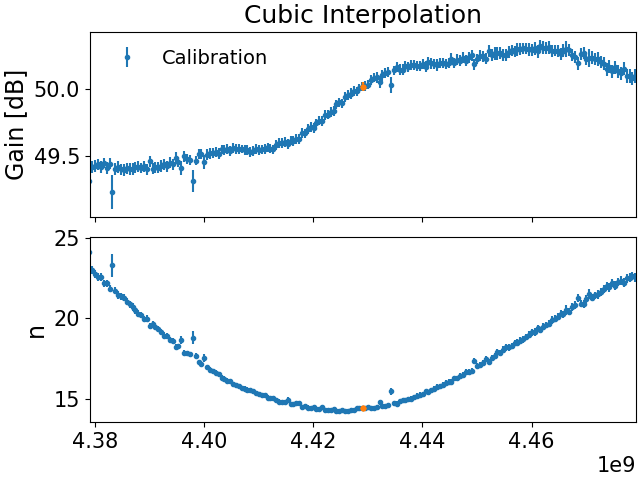

In [5]:
idx_str = '{}/{}'.format(run, 0)
attr_str = '{}'.format(run)

# Load metadata only — never pull the full USB ON/OFF arrays into memory
with h5py.File(file, 'r') as dataset:
        freq_arr = np.asarray(dataset[idx_str]['freq comb'])
        df = dataset[attr_str].attrs['df']
        Npixels = dataset[attr_str].attrs['Npixels']
        N_total = dataset[idx_str]['USB ON'].shape[0]

# Symplectic matrix
J_matrix = np.array([[0, 1], [-1, 0]])
symp_mat = np.block([[(J_matrix if v == j else np.zeros_like(J_matrix, dtype=complex))
                        for v in range(len(freq_arr))] for j in range(len(freq_arr))])

Zc = 50
pts_chunk = Npixels
N_chunks = (N_total + pts_chunk - 1) // pts_chunk

##############################################################################
# INTERPOLATION OF THE GAIN AND ADDED PHOTON NUMBER AT OPERATIONAL FREQUENCIES
##############################################################################

# Interpolation gain function
f_gain = interp1d(freq_arr_c, gain_c, kind='linear', fill_value="extrapolate")
# Gain at the measured frequencies
gain = f_gain(freq_arr)
# Interpolation n function
f_n = interp1d(freq_arr_c, n_c, kind='zero', fill_value="extrapolate")
# n at the measured frequencies
n = f_n(freq_arr)

# ERRORS
# Gain of the signal error bars
f_gain_up = interp1d(freq_arr_c, gain_c + gain_std_c, kind='cubic', fill_value="extrapolate")
gain_up = f_gain_up(freq_arr)
f_gain_down = interp1d(freq_arr_c, gain_c - gain_std_c, kind='cubic', fill_value="extrapolate")
gain_down = f_gain_down(freq_arr)
gain_std = (gain_up - gain_down) / 2
# n error bars
f_n_up = interp1d(freq_arr_c, n_c + n_std_c, kind='cubic', fill_value="extrapolate")
n_up = f_n_up(freq_arr)
f_n_down = interp1d(freq_arr_c, n_c - n_std_c, kind='cubic', fill_value="extrapolate")
n_down = f_n_down(freq_arr)
n_std = (n_up - n_down) / 2


################ Plot of the gain and n #########################
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].errorbar(freq_arr_c, gain_c, yerr=gain_std_c, fmt='.', label='Calibration')
ax[0].errorbar(freq_arr, gain, yerr=gain_std, fmt='.')
ax[0].set_ylabel('Gain [dB]')
ax[0].set_title('Cubic Interpolation')
ax[1].errorbar(freq_arr_c, n_c, yerr=n_std_c, fmt='.', label='Calibration')
ax[1].errorbar(freq_arr, n, yerr=n_std, fmt='.')
ax[1].set_xlim(np.min(freq_arr)-0.05e9, np.max(freq_arr)+0.05e9)
ax[1].set_ylabel('n')
ax[0].legend()

# Matrix building
# G (gain) matrix
G = np.diag(10 ** (np.repeat(gain, 2, axis=0) / 10))
# G^{-1/2}: two-sided gain correction (correct for covariance matrices)
G_sqrt_inv = np.diag(1.0 / np.sqrt(np.diag(G)))
# N (added number of photons) matrix
n_xp = np.repeat(n, 2, axis=0)
N = np.diag(n_xp)


plt.show()


# TESTING
----

## T.1 Raw covariance

In [16]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Uses G_sqrt_inv, N, Zc, df, freq_arr, idx_str, pts_chunk from the last main-loop iteration.
# To analyse a different amplitude: change pump_amp_idx and re-run the main loop.

# Scale: raw voltage → quadrature in sqrt(photons), with factor-of-2 normalisation
scale_test = np.sqrt(0.5607129 / (2 * Zc * df * Planck * freq_arr))  # shape (N_modes,)

# Load the SAME window as the covariance matrix plotted in the main loop (Vq_on_b[0]).
# Using the full dataset averages away the anti-diagonal due to slow phase drift across
# the measurement — the same mechanism as chunk-averaging from the old approach.
# To explore a different window change the slice below, e.g. [pts_chunk:2*pts_chunk].

pump_amp_idx =2

idx_str = '{}/{}'.format(run, pump_amp_idx)

with h5py.File(file, 'r') as dataset:
    usb_off_raw = dataset[idx_str]['USB OFF'][:]   # load into memory while file is open
    usb_on_raw  = dataset[idx_str]['USB ON'][:]
    print('data acquired')
usb_off_scaled = usb_off_raw * scale_test
del usb_off_raw

V_raw_off = covariance_matrix2(usb_off_scaled)
del usb_off_scaled

usb_on_scaled = usb_on_raw * scale_test
del usb_on_raw

V_raw_on = covariance_matrix2(usb_on_scaled)
del usb_on_scaled

### PUMP OFF COVARIANCE IN PHOTON NUMBER ###
# DE-AMPLIFICATION
V_deamp_off = G_sqrt_inv @ V_raw_off @ G_sqrt_inv

print(np.diag(V_deamp_off), np.diag(N))
# REMOVE ADDED PHOTONS

V_photons_off = V_deamp_off

for i in range(np.shape(V_deamp_off)[0]):
    V_photons_off[i, i] = V_photons_off[i, i] / (2 * (N[i, i] +1))
#V_photons_off = V_deamp_off- N - 0.5 * np.eye(np.shape(N)[0])  #

### PUMP ON COVARIANCE IN PHOTON NUMBER ###
V_photons_on = (G_sqrt_inv @ (V_raw_on - V_raw_off) @ G_sqrt_inv) + V_photons_off

data acquired
[14.90720844 14.90030709 14.89425013 14.91128954 14.89959723 14.91290135
 14.89141326 14.87485493 14.92218014 14.93827855] [14.3805624 14.3805624 14.3805624 14.3805624 14.3805624 14.3805624
 14.3805624 14.3805624 14.3805624 14.3805624]


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable

theta_slider = widgets.SelectionSlider(
    options=[(f'{k*0.05:.2f}π', k * 0.05 * np.pi) for k in range(21)],
    value=0.2 * np.pi,
    description='θ',
    continuous_update=False,
    layout=widgets.Layout(width='500px'),
)

out = widgets.Output()

def update_plot(theta):
    out.clear_output(wait=True)
    plot = cov_rotation(V_photons_on, theta)

    v_eigs = np.sort(np.linalg.eigvals(plot))
    v_diag = np.diag(plot)
    v_diag_avg = np.mean(v_diag)

    vmax = np.max(np.abs(plot))
    vmin = -vmax

    with out:
        fig, ax = plt.subplots(figsize=(15, 6), ncols=2)
        ax1, ax2 = ax

        im = ax1.imshow(plot, cmap='coolwarm', origin='upper', vmin=vmin, vmax=vmax)
        ax1.set_title('Covariance matrix, pump amp = ' + str(np.round(amp_pump[pump_amp_idx], 3))
                      + f',  θ = {theta/np.pi:.2f}π')
        divider = make_axes_locatable(ax1)
        cax = divider.append_axes("right", size="5%", pad=0.08)
        fig.colorbar(im, cax=cax)

        ax2.scatter(np.arange(2 * len(freq_arr)), v_eigs, label='eigenvalues', c='blue')
        ax2.scatter(np.arange(2 * len(freq_arr)), v_diag, label='diagonal', c='orange')
        ax2.axhline(y=0.5, c='red', ls='--')
        ax2.axhline(y=v_diag_avg, c='purple', ls='--', label='diagonal average')
        ax2.grid(alpha=0.7)
        ax2.set_xlim(left=0)
        ax2.legend()
        ax2.set_ylim(bottom=0, top=1)

        plt.show()

theta_slider.observe(lambda change: update_plot(change['new']), names='value')
display(theta_slider, out)
update_plot(theta_slider.value)


SelectionSlider(continuous_update=False, description='θ', index=4, layout=Layout(width='500px'), options=(('0.…

Output()

## T.2 Single-mode squeezing

In [18]:
m = len(freq_arr)

rows = [m-1, m]
cols = rows

V_reduced = V_photons_on[np.ix_(rows, cols)]

sqz, asqz = 10 * np.log10(np.sort(np.linalg.eigvals(V_reduced))/0.5)
print(sqz, asqz)

-0.9603297459993131 1.5341054355547303
